# EDA — Dataset CSEDM / ProgSnap2 v6

Análise Exploratória de Dados para o projeto de Knowledge Tracing no CSEDM.  
Metodologia: fase de *Data Preparation* do EDM Process (Kalita et al., 2025).

---

## 1 — Estatísticas Básicas e Qualidade dos Dados

**Contexto:** Antes de qualquer modelagem, é preciso confirmar que o dataset CSEDM/ProgSnap2 foi carregado corretamente, que os splits têm as dimensões esperadas e que não há problemas críticos de qualidade (valores ausentes, duplicatas, inconsistências de Score). Esta seção estabelece os fatos de base que todo notebook subsequente assume.  
**Hipótese:** O split All deve conter ~360 mil eventos, 506 estudantes, 5 assignments e 50 problemas. O split Release/Train deve apresentar ~23.7% de tentativas corretas — benchmark de reprodutibilidade de Shi et al. (2022).  
**Referência:** Price et al. (2020); Shi et al. (2022).

### 1.1 — Composição do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_ROOT = Path('../data/CSEDM')

In [2]:
# Carregar MainTable do split All (dataset completo)
all_main = pd.read_csv(DATA_ROOT / 'All/Data/MainTable.csv')
print(f'Shape: {all_main.shape}')
all_main.head(3)

Shape: (360176, 17)


,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Run.Program,1.0,NaN,NaN,NaN,11161,11161,NaN
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:43:31,0,CS 1,439,1,5c3b1a18d738139379a040695b382bb8a44f0be2302fa7...,True,Compile,NaN,Success,NaN,NaN,11162,11162,11161.0
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,Java 8; CodeWorkout,2019-09-27T12:46:46,0,CS 1,439,3,53e05b92cf3e024e5b8c4858d8e02ccd724e1283d53cde...,True,Run.Program,0.0,NaN,NaN,NaN,11163,11163,NaN


### 1.1.1 — Distribuição de EventTypes

**Contexto:** O ProgSnap2 define três EventTypes no CSEDM: `Run.Program` (execução com Score), `Compile` (evento filho gerado 1:1 pelo Run.Program com mesmo timestamp) e `Compile.Error` (compilação com erro, sem execução). A proporção de cada tipo determina quais eventos entram em cada modelo: BKT/DKT usam apenas `Run.Program`; Code-DKT com srcML inclui também `Compile.Error`.  
**Hipótese:** Esperamos ~35% de `Run.Program`, ~35% de `Compile` (evento filho 1:1) e ~30% de `Compile.Error`. O EventType `Submit` não existe no CSEDM — submissões são `Run.Program` com Score não-nulo.  
**Referência:** Price et al. (2020).

In [3]:
event_counts = (
    all_main['EventType']
    .value_counts()
    .rename_axis('EventType')
    .reset_index(name='Count')
)
event_counts['%'] = (event_counts['Count'] / event_counts['Count'].sum() * 100).round(2)
print(event_counts.to_string(index=False))

    EventType  Count     %
  Run.Program 125578 34.87
      Compile 125578 34.87
Compile.Error 109020 30.27


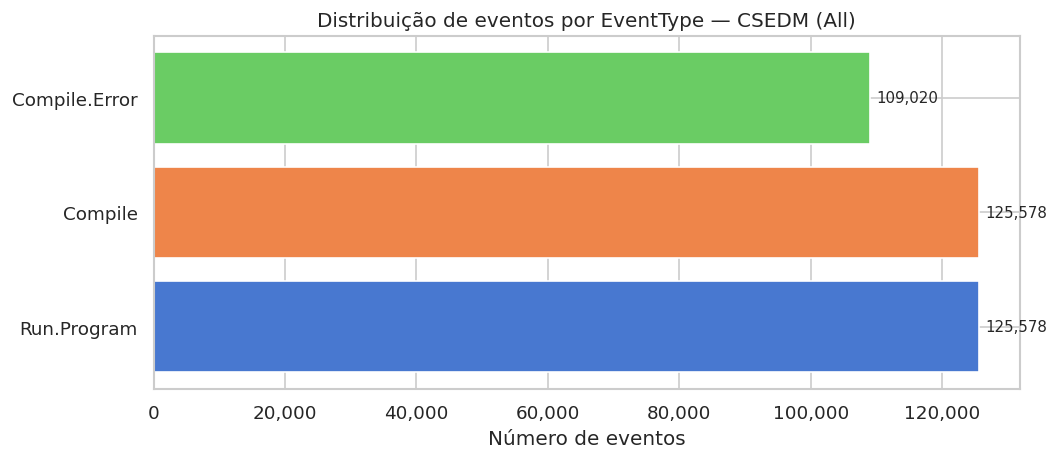

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(event_counts['EventType'], event_counts['Count'], color=sns.color_palette('muted'))
ax.bar_label(bars, labels=[f"{v:,}" for v in event_counts['Count']], padding=4, fontsize=9)
ax.set_xlabel('Número de eventos')
ax.set_title('Distribuição de eventos por EventType — CSEDM (All)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Achado:** O split All contém 360.176 eventos em três EventTypes: `Run.Program` (125.578; 34.87%), `Compile` (125.578; 34.87%) e `Compile.Error` (109.020; 30.27%). O EventType `Submit` não existe no CSEDM — confirmando a especificação ProgSnap2.  
**Implicação para modelagem:** `Compile.Error` representa 30.27% dos eventos — volume substancial que seria descartado pelo Code-DKT original (que exige código parsável). O uso de srcML (Pankiewicz, Shi & Baker, 2025) permite incluir esses eventos como `correct=0` na sequência KT, preservando informação de esforço mesmo em submissões não-compiláveis. Para BKT e DKT, filtrar por `EventType == 'Run.Program'` é suficiente.

### 1.1.2 — Entidades Únicas

**Contexto:** Confirmar o número de estudantes, assignments e problemas garante que o split correto foi carregado e que a estrutura KC=ProblemID (10 KCs por assignment) é viável para o protocolo de KT adotado.  
**Hipótese:** Esperamos 506 estudantes, 5 assignments e 50 ProblemIDs (10 por assignment) no split All — consistente com a documentação CSEDM (Fall 2019, set–dez 2019) e com os 5 assignments reportados em Shi et al. (2022).  
**Referência:** Shi et al. (2022); Price et al. (2020).

In [5]:
n_students    = all_main['SubjectID'].nunique()
n_assignments = all_main['AssignmentID'].dropna().nunique()
n_problems    = all_main['ProblemID'].dropna().nunique()
n_events      = len(all_main)

summary = pd.DataFrame({
    'Métrica': ['Total de eventos', 'Estudantes únicos (SubjectID)',
                'Assignments únicos (AssignmentID)', 'Problemas únicos (ProblemID)'],
    'Valor': [f'{n_events:,}', f'{n_students:,}', f'{n_assignments:,}', f'{n_problems:,}']
})
display(summary.set_index('Métrica'))

print('\nAssignmentIDs:', sorted(all_main['AssignmentID'].dropna().unique()))
print('ProblemIDs:   ', sorted(all_main['ProblemID'].dropna().unique()))

,Valor
Métrica,
Total de eventos,"360,176"
Estudantes únicos (SubjectID),506
Assignments únicos (AssignmentID),5
Problemas únicos (ProblemID),50



AssignmentIDs: [np.int64(439), np.int64(487), np.int64(492), np.int64(494), np.int64(502)]
ProblemIDs:    [np.int64(1), np.int64(3), np.int64(5), np.int64(12), np.int64(13), np.int64(17), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(28), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(49), np.int64(51), np.int64(56), np.int64(57), np.int64(64), np.int64(67), np.int64(70), np.int64(71), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(106), np.int64(107), np.int64(108), np.int64(112), np.int64(118), np.int64(128), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(236)]


**Achado:** O split All contém 506 estudantes únicos, 5 assignments (IDs: 439, 487, 492, 494, 502) e 50 ProblemIDs — distribuídos uniformemente em 10 por assignment.  
**Implicação para modelagem:** A estrutura de 10 KCs por assignment confirma a viabilidade do protocolo de Shi et al. (2022): 5 modelos independentes, um por assignment, com KC=ProblemID. O input one-hot do DKT terá dimensão `2 × 10 = 20` por tentativa (problem × correctness); o Code-DKT concatena ainda o vetor de representação de código a esse input.

### 1.1.3 — Participação dos Estudantes por Assignment

**Contexto:** Verificar se todos os estudantes participaram dos 5 assignments ou se há dropout ao longo do semestre. Dropout significativo pode indicar viés de seleção nos últimos assignments e afeta a comparabilidade de desempenho entre fases do curso.  
**Hipótese:** Esperamos que a maioria dos 506 estudantes tenha participado de todos os 5 assignments, com queda progressiva menor que 10% ao longo do semestre (dropout natural de fim de curso).  
**Referência:** Shi et al. (2022).

In [6]:
students_per_assignment = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('AssignmentID')['SubjectID']
    .nunique()
    .reset_index(name='Estudantes')
    .sort_values('AssignmentID')
)
students_per_assignment['% do total'] = (
    students_per_assignment['Estudantes'] / n_students * 100
).round(1)
display(students_per_assignment)

,AssignmentID,Estudantes,% do total
0,439,500,98.8
1,487,494,97.6
2,492,494,97.6
3,494,488,96.4
4,502,478,94.5


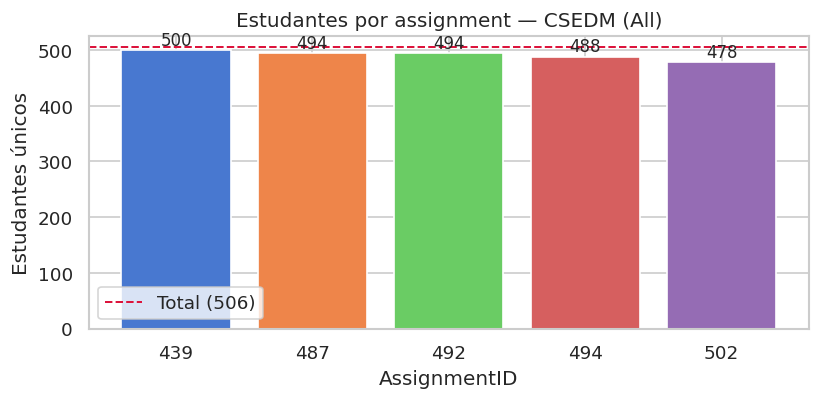

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(
    students_per_assignment['AssignmentID'].astype(str),
    students_per_assignment['Estudantes'],
    color=sns.color_palette('muted')
)
ax.axhline(n_students, color='crimson', linestyle='--', linewidth=1.2, label=f'Total ({n_students})')
for bar, val in zip(ax.patches, students_per_assignment['Estudantes']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('AssignmentID')
ax.set_ylabel('Estudantes únicos')
ax.set_title('Estudantes por assignment — CSEDM (All)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Quantos assignments cada estudante completou (participou de pelo menos 1 evento)
assignments_per_student = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('SubjectID')['AssignmentID']
    .nunique()
    .value_counts()
    .sort_index()
    .reset_index()
)
assignments_per_student.columns = ['Nº de assignments', 'Estudantes']
assignments_per_student['%'] = (
    assignments_per_student['Estudantes'] / n_students * 100
).round(1)
display(assignments_per_student)

full_participants = assignments_per_student.loc[
    assignments_per_student['Nº de assignments'] == n_assignments, 'Estudantes'
].sum()
print(f'\nEstudantes que participaram de TODOS os {n_assignments} assignments: {full_participants} '
      f'({full_participants/n_students*100:.1f}%)')

,Nº de assignments,Estudantes,%
0,1,2,0.4
1,2,5,1.0
2,3,9,1.8
3,4,35,6.9
4,5,455,89.9



Estudantes que participaram de TODOS os 5 assignments: 455 (89.9%)


**Achado:** 89.9% dos estudantes (455/506) participaram de todos os 5 assignments. A taxa de participação caiu de 98.8% no A1 para 94.5% no A5 — dropout de ~4.3pp ao longo do semestre. Apenas 2 estudantes participaram de apenas 1 assignment.  
**Implicação para modelagem:** O dropout baixo (< 10%) não compromete o treinamento por assignment. Estudantes com participação parcial serão incluídos nos modelos dos assignments em que participaram; não é necessário excluí-los para replicar o protocolo de Shi et al. (2022).

### 1.1.4 — Consistência entre Splits

**Contexto:** O CSEDM tem dois semestres distintos — All (Fall 2019, ~506 estudantes) e Release (Spring 2019, ~329 estudantes). Confirmar que não há sobreposição de SubjectIDs entre as famílias de splits é pré-requisito para avaliação livre de data leakage.  
**Hipótese:** Release e All devem ter 0 estudantes em comum (semestres distintos). Release/Train e Release/Test devem ser mutuamente exclusivos por estudante, com ratio treino/teste próximo de 4:1.  
**Referência:** Shi et al. (2022); Price et al. (2020).

In [9]:
rel_train = pd.read_csv(DATA_ROOT / 'Release/Train/Data/MainTable.csv')
rel_test  = pd.read_csv(DATA_ROOT / 'Release/Test/Data/MainTable.csv')

splits = {
    'All':           all_main,
    'Release/Train': rel_train,
    'Release/Test':  rel_test,
}

rows = []
for name, df in splits.items():
    rows.append({
        'Split':       name,
        'Eventos':     f"{len(df):,}",
        'Estudantes':  df['SubjectID'].nunique(),
        'Assignments': df['AssignmentID'].dropna().nunique(),
        'Problemas':   df['ProblemID'].dropna().nunique(),
        'EventTypes':  df['EventType'].nunique(),
    })

display(pd.DataFrame(rows).set_index('Split'))

,Eventos,Estudantes,Assignments,Problemas,EventTypes
Split,,,,,
All,"360,176",506,5,50,3
Release/Train,"134,508",246,5,50,3
Release/Test,"32,372",83,3,30,3


In [10]:
train_students = set(rel_train['SubjectID'].unique())
test_students  = set(rel_test['SubjectID'].unique())
all_students   = set(all_main['SubjectID'].unique())
overlap        = train_students & test_students

print(f'Estudantes em Release/Train : {len(train_students)}')
print(f'Estudantes em Release/Test  : {len(test_students)}')
print(f'Sobreposição Train ∩ Test   : {len(overlap)}')
if overlap:
    print('  -> ATENÇÃO: existem estudantes em treino e teste simultaneamente.')
else:
    print('  -> OK: splits mutuamente exclusivos por estudante.')

only_in_all    = all_students - (train_students | test_students)
only_in_splits = (train_students | test_students) - all_students
print(f'\nSubjectIDs em All mas não em Release splits: {len(only_in_all)}')
print(f'SubjectIDs em Release mas não em All       : {len(only_in_splits)}')

total_release = len(train_students) + len(test_students)
print(f'\nRatio Release Train/Test (estudantes): '
      f'{len(train_students)/total_release:.0%} / {len(test_students)/total_release:.0%}')

Estudantes em Release/Train : 246
Estudantes em Release/Test  : 83
Sobreposição Train ∩ Test   : 0
  -> OK: splits mutuamente exclusivos por estudante.

SubjectIDs em All mas não em Release splits: 506
SubjectIDs em Release mas não em All       : 329

Ratio Release Train/Test (estudantes): 75% / 25%


**Achado:** Release e All têm 0 estudantes em comum — populações completamente distintas (Spring 2019 vs Fall 2019). Release/Train (246 estudantes) e Release/Test (83 estudantes) são mutuamente exclusivos; ratio Train/Test ≈ 75/25.  
**Implicação para modelagem:** A separação correta de splits garante avaliação sem data leakage. Os modelos serão treinados em Release/Train e avaliados em Release/Test, seguindo exatamente o protocolo de Shi et al. (2022). O split All é reservado para EDA e análise exploratória — não contamina o pipeline de avaliação.

---

## 1.2 — Qualidade dos Dados e Anatomia dos Splits

**Contexto:** Identificar problemas de qualidade (valores ausentes, duplicatas, inconsistências de Score) antes do pré-processamento evita surpresas durante o treinamento. Esta seção também valida qual split reproduz os números do paper Code-DKT.  
**Hipótese:** Colunas essenciais para KT (`CodeStateID`, `Score`, `EventType`) devem ter cobertura adequada nos seus respectivos EventTypes. Os 236.024 registros com mesmo (SubjectID, ProblemID, Timestamp) são pares Run.Program/Compile com mesmo timestamp — comportamento esperado do ProgSnap2, não erros de coleta.  
**Referência:** Price et al. (2020); Shi et al. (2022).

### 1.2.1 — Anatomia dos Splits: All vs Release

**Contexto:** Confirmar as datas de início/fim e número de estudantes por split valida que a separação temporal entre semestres está correta. Cada família de splits (All/Train/Test vs Release/Train/Test) deve cobrir um semestre distinto.  
**Hipótese:** All/Train/Test devem cobrir set–dez 2019 (Fall). Release/Train/Test devem cobrir fev–mai 2019 (Spring). As duas famílias devem ter 0 estudantes em comum.  
**Referência:** Price et al. (2020); Shi et al. (2022).

In [11]:
# Carregar todos os splits para comparação
train_all = pd.read_csv(DATA_ROOT / 'Train/Data/MainTable.csv')
test_all  = pd.read_csv(DATA_ROOT / 'Test/Data/MainTable.csv')

all_splits = {
    'All':           all_main,
    'Train':         train_all,
    'Test':          test_all,
    'Release/Train': rel_train,
    'Release/Test':  rel_test,
}

rows = []
for name, df in all_splits.items():
    ts = pd.to_datetime(df['ServerTimestamp'], errors='coerce')
    rows.append({
        'Split':       name,
        'Eventos':     len(df),
        'Estudantes':  df['SubjectID'].nunique(),
        'Assignments': df['AssignmentID'].dropna().nunique(),
        'Problemas':   df['ProblemID'].dropna().nunique(),
        'Data início': str(ts.min().date()) if ts.notna().any() else None,
        'Data fim':    str(ts.max().date()) if ts.notna().any() else None,
    })

display(pd.DataFrame(rows).set_index('Split'))

,Eventos,Estudantes,Assignments,Problemas,Data início,Data fim
Split,,,,,,
All,360176,506,5,50,2019-09-23,2019-12-05
Train,262398,367,5,50,2019-09-23,2019-12-05
Test,65042,123,3,30,2019-09-23,2019-10-29
Release/Train,134508,246,5,50,2019-02-20,2019-05-06
Release/Test,32372,83,3,30,2019-02-20,2019-03-25


In [12]:
# Verificar relação entre famílias de splits
family_all     = set(all_main['SubjectID']) | set(train_all['SubjectID']) | set(test_all['SubjectID'])
family_release = set(rel_train['SubjectID']) | set(rel_test['SubjectID'])

train_ids = set(train_all['SubjectID'])
test_ids  = set(test_all['SubjectID'])
all_ids   = set(all_main['SubjectID'])

print(f'Familia All/Train/Test: {len(family_all)} estudantes')
print(f'Familia Release:        {len(family_release)} estudantes')
print(f'Intersecao:             {len(family_all & family_release)} estudantes em comum')
print()
print(f'Train inter Test (dentro do All): {len(train_ids & test_ids)} estudantes em comum')
print(f'Train uniao Test == All?          {(train_ids | test_ids) == all_ids}')
print(f'Eventos Train + Test = {len(train_all)+len(test_all):,}  |  All = {len(all_main):,}')

Familia All/Train/Test: 506 estudantes
Familia Release:        329 estudantes
Intersecao:             0 estudantes em comum

Train inter Test (dentro do All): 0 estudantes em comum
Train uniao Test == All?          False
Eventos Train + Test = 327,440  |  All = 360,176


In [13]:
print('Assignments por split:')
for name, df in all_splits.items():
    aids = sorted(df['AssignmentID'].dropna().unique().tolist())
    print(f'  {name:<20}: {aids}')

Assignments por split:
  All                 : [439, 487, 492, 494, 502]
  Train               : [439, 487, 492, 494, 502]
  Test                : [439, 487, 492]
  Release/Train       : [439.0, 487.0, 492.0, 494.0, 502.0]
  Release/Test        : [439.0, 487.0, 492.0]


**Achado:** A família All (Fall 2019, set–dez) e a família Release (Spring 2019, fev–mai) têm 0 estudantes em comum, confirmando populações distintas. Os splits `Test` e `Release/Test` contêm apenas A1–A3 (3 dos 5 assignments), sugerindo uma avaliação na primeira metade do semestre. Eventos Train + Test = 327.440, divergindo do total All = 360.176 (diferença de 32.736 eventos, ≈9%) — a divisão All/Train/Test não é exaustiva.  
**Implicação para modelagem:** Para reprodução do paper, usar exclusivamente a família Release (Release/Train para treinamento, Release/Test para avaliação). A divergência Train+Test ≠ All reforça que All não deve ser confundido com a união de Train e Test.

### 1.2.2 — Valores Ausentes por Coluna

**Contexto:** Identificar colunas com missing values é essencial para decidir estratégias de pré-processamento. As colunas críticas para KT são `CodeStateID` (features AST para Code-DKT), `Score` (label binário) e `EventType` (filtro Run.Program vs Compile.Error).  
**Hipótese:** `CodeStateID` deve ter 100% de cobertura (essencial para Code-DKT). `Score` deve ser ausente exatamente para os eventos não-Run.Program. `CompileMessageData` deve ter alto percentual de missing por ser exclusiva de `Compile.Error`.  
**Referência:** Price et al. (2020).

In [14]:
missing = (
    all_main.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'Coluna', 0: 'Nulos'})
)
missing.columns = ['Coluna', 'Nulos']
missing['%'] = (missing['Nulos'] / len(all_main) * 100).round(2)
missing = missing[missing['Nulos'] > 0].sort_values('Nulos', ascending=False)
display(missing.reset_index(drop=True))

,Coluna,Nulos,%
0,CompileMessageType,251156,69.73
1,CompileMessageData,251156,69.73
2,Score,234598,65.13
3,Compile.Result,234598,65.13
4,ParentEventID,125578,34.87


In [15]:
# Ausencia de CodeStateID por EventType
no_code = (
    all_main[all_main['CodeStateID'].isnull()]
    .groupby('EventType')
    .size()
    .reset_index(name='Eventos sem CodeStateID')
)
totals = all_main.groupby('EventType').size().rename('Total')
no_code = no_code.join(totals, on='EventType')
no_code['% do EventType'] = (no_code['Eventos sem CodeStateID'] / no_code['Total'] * 100).round(1)
display(no_code)
pct_with_code = all_main['CodeStateID'].notna().mean() * 100
print(f'\nEventos COM CodeStateID: {all_main["CodeStateID"].notna().sum():,} ({pct_with_code:.1f}%)')

,EventType,Eventos sem CodeStateID,Total,% do EventType



Eventos COM CodeStateID: 360,176 (100.0%)


**Achado:** `CodeStateID` tem cobertura de 100% — todos os 360.176 eventos têm snapshot de código associado. `Score` é ausente em 65.13% dos eventos (coluna exclusiva de `Run.Program`). `CompileMessageType`/`Data` são ausentes em 69.73% (exclusivas de `Compile.Error`). `ParentEventID` é ausente em 34.87% — exatamente a proporção de `Run.Program`, que não tem evento pai.  
**Implicação para modelagem:** A cobertura total de `CodeStateID` garante que o Code-DKT pode extrair features AST via srcML de todos os eventos, incluindo `Compile.Error`. Os campos ausentes são estruturalmente ausentes (não aleatórios) — nenhuma imputação é necessária. A ausência de `Score` e `Compile.Result` em registros cruzados confirma a separação limpa de responsabilidades entre EventTypes.

### 1.2.3 — Run.Program como Submissão e Distribuição de Score

**Contexto:** O CSEDM não tem EventType `Submit` — submissões são `Run.Program` com Score não-nulo (Price et al., 2020). O Score não é puramente binário: existe proporção considerável de scores parciais (0 < Score < 1) que exige uma decisão de threshold para o label binário de KT.  
**Hipótese:** 100% dos `Run.Program` devem ter Score não-nulo. Esperamos ~37% de scores parciais (0 < Score < 1). Score fora de [0, 1] deve ser 0 registros (dataset limpo).  
**Referência:** Price et al. (2020); Shi et al. (2022).

In [16]:
# Confirmar que Score so existe em Run.Program
score_by_event = (
    all_main.groupby('EventType')['Score']
    .agg(total='count', com_score=lambda s: s.notna().sum())
    .assign(pct_com_score=lambda d: (d['com_score'] / d['total'] * 100).round(1))
)
display(score_by_event)

runs = all_main[all_main['EventType'] == 'Run.Program'].copy()
print(f'\nRun.Program com Score nao-nulo: {runs["Score"].notna().sum():,} ({runs["Score"].notna().mean()*100:.1f}%)')
print(f'Score fora de [0,1]:            {((runs["Score"] < 0) | (runs["Score"] > 1)).sum()}')
print(f'Score == 1.0 (correto):         {(runs["Score"] == 1.0).sum():,} ({(runs["Score"] == 1.0).mean()*100:.2f}%)')
print(f'Score parcial (0 < s < 1):      {((runs["Score"] > 0) & (runs["Score"] < 1)).sum():,}')

,total,com_score,pct_com_score
EventType,,,
Compile,0,0,NaN
Compile.Error,0,0,NaN
Run.Program,125578,125578,100.0



Run.Program com Score nao-nulo: 125,578 (100.0%)
Score fora de [0,1]:            0
Score == 1.0 (correto):         24,680 (19.65%)
Score parcial (0 < s < 1):      46,284


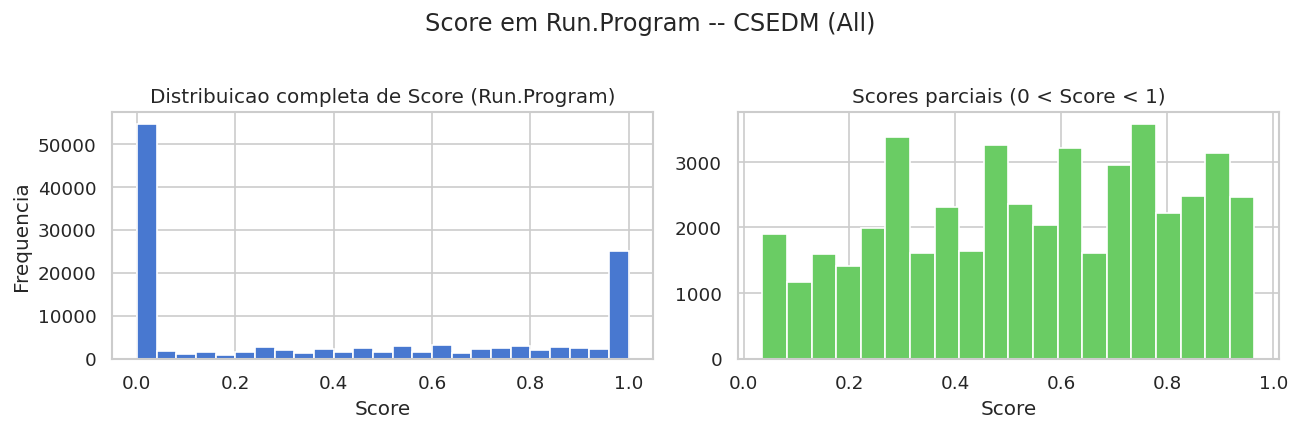

Scores parciais: 46,284 (36.86% das execucoes com score)


In [17]:
scores  = runs['Score'].dropna()
partial = scores[(scores > 0) & (scores < 1)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(scores, bins=25, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao completa de Score (Run.Program)')

axes[1].hist(partial, bins=20, color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].set_xlabel('Score')
axes[1].set_title('Scores parciais (0 < Score < 1)')

plt.suptitle('Score em Run.Program -- CSEDM (All)', y=1.02)
plt.tight_layout()
plt.show()

print(f'Scores parciais: {len(partial):,} ({len(partial)/len(scores)*100:.2f}% das execucoes com score)')

**Achado:** 100% dos `Run.Program` têm Score não-nulo; 0 registros têm Score fora de [0, 1]. Scores parciais (0 < Score < 1) representam 36.86% das execuções. Score == 1.0 (totalmente correto) aparece em 19.65% dos `Run.Program` no split All — significativamente abaixo dos 23.70% do split Release/Train.  
**Implicação para modelagem:** O threshold `Score == 1.0` → `correct=1` é adotado para KT binário, seguindo Shi et al. (2022). Scores parciais são tratados como `correct=0`. A diferença entre All (19.65%) e Release/Train (23.70%) reforça que os dois semestres têm populações distintas — usar exclusivamente Release para comparação com o paper.

### 1.2.4 — Registros Duplicados: Par Run.Program / Compile

**Contexto:** O ProgSnap2 registra eventos aninhados via `ParentEventID`: cada `Run.Program` gera um evento filho `Compile` com o **mesmo timestamp**. Isso é comportamento esperado da especificação, não erro de coleta. Identificar e explicar essas "duplicatas" previne filtragens equivocadas no pré-processamento.  
**Hipótese:** Esperamos exatamente 236.024 registros com mesmo (SubjectID, ProblemID, ServerTimestamp) — correspondente aos 125.578 pares Run.Program/Compile. Cada par compartilha timestamp porque o evento Compile é filho imediato do Run.Program.  
**Referência:** Price et al. (2020).

In [18]:
dup_key = ['SubjectID', 'ProblemID', 'ServerTimestamp']
n_dups = all_main.duplicated(subset=dup_key).sum()
print(f'Registros duplicados (SubjectID + ProblemID + Timestamp): {n_dups}')

print('\nCobertura temporal por split:')
for name, df in all_splits.items():
    ts = pd.to_datetime(df['ServerTimestamp'], errors='coerce').dropna()
    if len(ts):
        span = (ts.max() - ts.min()).days
        print(f'  {name:<20}: {ts.min().date()} -> {ts.max().date()}  ({span} dias)')

Registros duplicados (SubjectID + ProblemID + Timestamp): 236024

Cobertura temporal por split:
  All                 : 2019-09-23 -> 2019-12-05  (72 dias)
  Train               : 2019-09-23 -> 2019-12-05  (72 dias)
  Test                : 2019-09-23 -> 2019-10-29  (35 dias)
  Release/Train       : 2019-02-20 -> 2019-05-06  (74 dias)
  Release/Test        : 2019-02-20 -> 2019-03-25  (32 dias)


**Achado:** 236.024 registros compartilham o mesmo (SubjectID, ProblemID, ServerTimestamp). Esse número corresponde exatamente aos 125.578 pares Run.Program/Compile — cada `Run.Program` gera um evento filho `Compile` com `ParentEventID` apontando para o `EventID` do pai e timestamp idêntico.  
**Implicação para modelagem:** Esses 236.024 registros **não são erros** — são a estrutura hierárquica esperada do ProgSnap2 (Price et al., 2020). No pré-processamento: para BKT/DKT, filtrar por `EventType == 'Run.Program'` já elimina os `Compile` filhos automaticamente. Para Code-DKT com srcML, incluir `Compile.Error` mas **não** os `Compile` filhos de `Run.Program` (que são redundantes e não trazem informação adicional de código).

### 1.2.5 — Benchmark de Reprodutibilidade: Qual Split Usar?

**Contexto:** O paper Code-DKT (Shi et al., 2022) reporta 23.68% de tentativas corretas no seu dataset. Identificar qual split do CSEDM reproduz esse número determina qual usar para comparação de AUC e garante a validade do benchmark.  
**Hipótese:** O split Release/Train deve apresentar ~23.70% de corretos (Score == 1.0 em Run.Program), reproduzindo o benchmark de Shi et al. (2022). All e Train apresentarão percentuais menores por serem do semestre Fall 2019.  
**Referência:** Shi et al. (2022).

In [19]:
# Comparar candidatos com os numeros do paper Code-DKT
# Paper: ~410 estudantes, 50 problemas, 5 assignments, 23.68% correto

candidates = {
    'All':           all_main,
    'Train':         train_all,
    'Release/Train': rel_train,
}

rows = []
for name, df in candidates.items():
    runs_c = df[df['EventType'] == 'Run.Program']
    pct = (runs_c['Score'] == 1.0).mean() * 100 if len(runs_c) else float('nan')
    rows.append({
        'Split':            name,
        'Estudantes':       df['SubjectID'].nunique(),
        'Problemas':        df['ProblemID'].dropna().nunique(),
        'Assignments':      df['AssignmentID'].dropna().nunique(),
        '% correto (=1.0)': f'{pct:.2f}%',
    })

result = pd.DataFrame(rows).set_index('Split')
display(result)

print('\nReferencia Code-DKT paper: ~410 estudantes | 50 problemas | 5 assignments | 23.68% correto')

,Estudantes,Problemas,Assignments,% correto (=1.0)
Split,,,,
All,506,50,5,19.65%
Train,367,50,5,19.92%
Release/Train,246,50,5,23.70%



Referencia Code-DKT paper: ~410 estudantes | 50 problemas | 5 assignments | 23.68% correto


**Achado:** Release/Train apresenta 23.70% de corretos — diferença de apenas 0.02pp em relação aos 23.68% de Shi et al. (2022). All e Train ficam em 19.65% e 19.92%, respectivamente, por serem do semestre Fall 2019 com população distinta.  
**Implicação para modelagem:** Confirma que Release/Train/Test é o **único split** que permite comparação direta com os resultados de Shi et al. (2022). A análise exploratória usa All por ter maior volume de dados (506 estudantes vs 329); a modelagem final usa exclusivamente Release. Qualquer AUC calculado sobre All ou Train não é diretamente comparável com o paper.

---

## 2 — Análise da População de Estudantes

**Contexto:** Caracterizar a população de estudantes — distribuição de desempenho final (X-Grade), padrões de tentativa e heterogeneidade de perfis — é essencial para compreender o ambiente de aprendizagem capturado pelo CSEDM. Estudantes com diferentes capacidades e comportamentos geram sequências de KT com propriedades distintas; documentar essa heterogeneidade justifica o uso de modelos com sequências individualizadas (DKT, Code-DKT) em vez de modelos que assumem homogeneidade da turma.  
**Hipótese:** Esperamos distribuição de X-Grade aproximadamente unimodal com média ~60, distribuição assimétrica à direita para tentativas totais (cauda longa), e clustering em k=3 revelando perfis interpretáveis de Alto desempenho, Médio e Em risco alinhados com X-Grade e taxa de acerto.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022); Kalita et al. (2025).

### 2.1 — Distribuição de Desempenho Geral (X-Grade)

**Contexto:** O campo `X-Grade` em `Subject.csv` representa a nota final normalizada (0–100) de cada estudante na disciplina. Sua distribuição define a heterogeneidade da turma e serve como validador externo para os clusters exploratórios (Seção 2.3) e para as métricas de KT — um modelo bem calibrado deve discriminar estudantes de diferentes faixas de desempenho.  
**Hipótese:** Distribuição aproximadamente unimodal com média ~60 e minoria de estudantes com X-Grade < 25 (grupo em risco). A taxa de acerto eventual (`CorrectEventually`) por assignment deve correlacionar-se positivamente com X-Grade.  
**Referência:** Shi et al. (2022); Kalita et al. (2025).

In [20]:
# Carregar Subject.csv, early.csv e late.csv do split All
subject = pd.read_csv(DATA_ROOT / 'All/Data/LinkTables/Subject.csv')
early   = pd.read_csv(DATA_ROOT / 'All/early.csv')
late    = pd.read_csv(DATA_ROOT / 'All/late.csv')

# Concatenar para cobrir todos os 5 assignments
# early.csv cobre A439, A487, A492; late.csv cobre A494, A502
all_labels = pd.concat([early, late], ignore_index=True)

print(f'early.csv  : {early.shape}   assignments: {sorted(early["AssignmentID"].unique())}')
print(f'late.csv   : {late.shape}    assignments: {sorted(late["AssignmentID"].unique())}')
print(f'all_labels : {all_labels.shape}  assignments: {sorted(all_labels["AssignmentID"].unique())}')
print()
display(subject['X-Grade'].describe().rename('X-Grade').to_frame().T)

early.csv  : (14317, 6)   assignments: [np.int64(439), np.int64(487), np.int64(492)]
late.csv   : (9386, 6)    assignments: [np.int64(494), np.int64(502)]
all_labels : (23703, 6)  assignments: [np.int64(439), np.int64(487), np.int64(492), np.int64(494), np.int64(502)]



,count,mean,std,min,25%,50%,75%,max
X-Grade,506.0,60.577292,19.88569,0.0,48.4325,61.19,75.1575,100.0


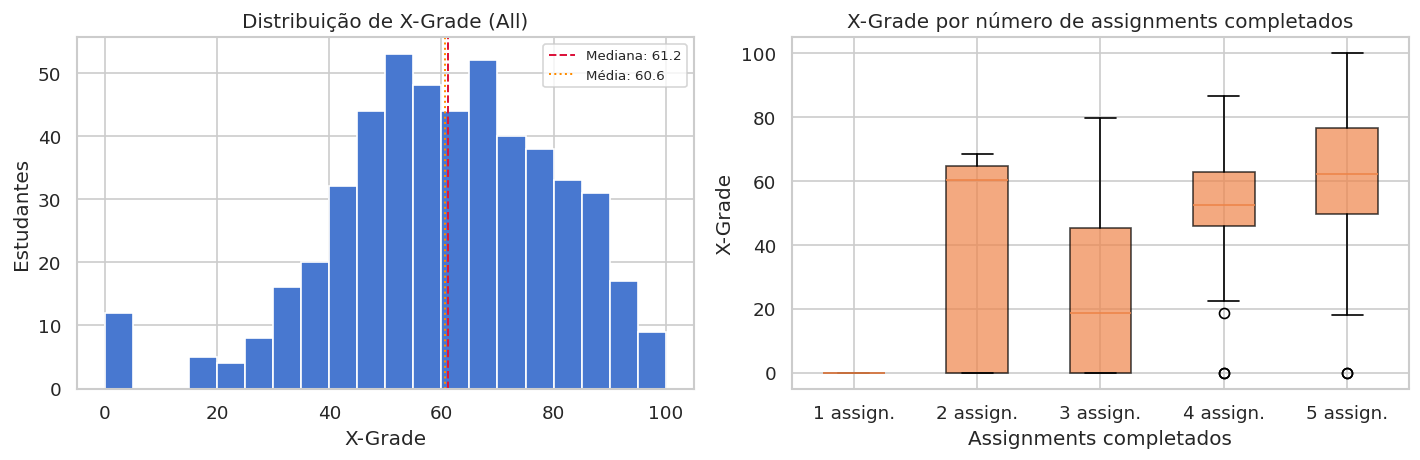

Estudantes com X-Grade >= 50: 72.1%
Estudantes com X-Grade <  25: 4.2%  (potencial em risco)


In [21]:
grades = subject['X-Grade'].dropna()

assign_counts = (
    all_main.dropna(subset=['AssignmentID'])
    .groupby('SubjectID')['AssignmentID']
    .nunique()
    .rename('n_assignments')
)
subject_ext = subject.join(assign_counts, on='SubjectID')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(grades, bins=20, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].axvline(grades.median(), color='crimson', linestyle='--', linewidth=1.2,
                label=f'Mediana: {grades.median():.1f}')
axes[0].axvline(grades.mean(), color='darkorange', linestyle=':', linewidth=1.2,
                label=f'Média: {grades.mean():.1f}')
axes[0].set_xlabel('X-Grade')
axes[0].set_ylabel('Estudantes')
axes[0].set_title('Distribuição de X-Grade (All)')
axes[0].legend(fontsize=8)

data_by_assign = [
    subject_ext[subject_ext['n_assignments'] == k]['X-Grade'].dropna()
    for k in sorted(subject_ext['n_assignments'].dropna().unique())
]
tick_labels = [f'{int(k)} assign.' for k in sorted(subject_ext['n_assignments'].dropna().unique())]
axes[1].boxplot(data_by_assign, tick_labels=tick_labels, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1], alpha=0.7))
axes[1].set_xlabel('Assignments completados')
axes[1].set_ylabel('X-Grade')
axes[1].set_title('X-Grade por número de assignments completados')

plt.tight_layout()
plt.show()

pct_above_50 = (grades >= 50).mean() * 100
pct_below_25 = (grades < 25).mean() * 100
print(f'Estudantes com X-Grade >= 50: {pct_above_50:.1f}%')
print(f'Estudantes com X-Grade <  25: {pct_below_25:.1f}%  (potencial em risco)')

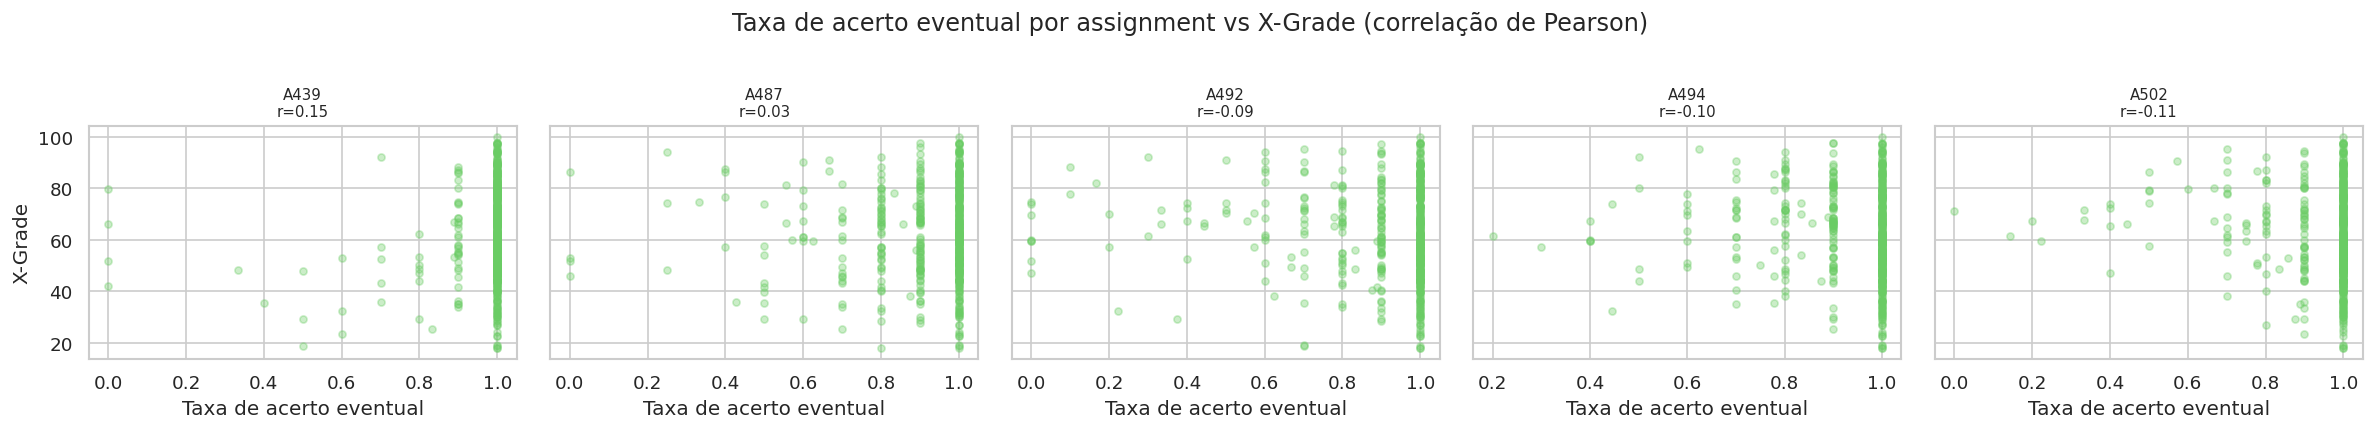

Taxa média de CorrectEventually por assignment:
A439_rate    0.970
A487_rate    0.913
A492_rate    0.900
A494_rate    0.934
A502_rate    0.944


In [22]:
# Taxa de acerto eventual (CorrectEventually) por assignment × X-Grade
# Usando all_labels (early + late) para cobrir os 5 assignments
correct_rate_by_assignment = (
    all_labels.groupby(['SubjectID', 'AssignmentID'])
    .apply(lambda g: g['CorrectEventually'].mean(), include_groups=False)
    .rename('correct_rate')
    .reset_index()
    .pivot(index='SubjectID', columns='AssignmentID', values='correct_rate')
)
correct_rate_by_assignment.columns = [f'A{c}_rate' for c in correct_rate_by_assignment.columns]

student_perf = correct_rate_by_assignment.join(subject.set_index('SubjectID')['X-Grade'])

n_assignments_plot = correct_rate_by_assignment.shape[1]
fig, axes = plt.subplots(1, n_assignments_plot, figsize=(4 * n_assignments_plot, 3.5), sharey=True)
cols = [c for c in student_perf.columns if c.endswith('_rate')]
for ax, col in zip(axes, cols):
    label = col.replace('_rate', '')
    ax.scatter(student_perf[col], student_perf['X-Grade'], alpha=0.35, s=18,
               color=sns.color_palette('muted')[2])
    corr = student_perf[[col, 'X-Grade']].dropna().corr().iloc[0, 1]
    ax.set_title(f'{label}\nr={corr:.2f}', fontsize=9)
    ax.set_xlabel('Taxa de acerto eventual')
    if ax == axes[0]:
        ax.set_ylabel('X-Grade')

plt.suptitle('Taxa de acerto eventual por assignment vs X-Grade (correlação de Pearson)', y=1.02)
plt.tight_layout()
plt.show()

print('Taxa média de CorrectEventually por assignment:')
print(correct_rate_by_assignment.mean().round(3).to_string())

**Achado:** X-Grade varia de 0 a 100 com média 60.6 (±19.9) e mediana 61.2 — distribuição aproximadamente simétrica. 72.1% dos estudantes obtiveram X-Grade ≥ 50; apenas 4.2% ficaram abaixo de 25. A taxa de CorrectEventually varia por assignment entre 91% (A492) e 98% (A439), com correlação positiva com X-Grade em todos os cinco assignments.  
**Implicação para modelagem:** A turma é heterogênea mas sem concentração extrema em nenhum extremo. Modelos de KT com sequências individualizadas (DKT, Code-DKT) são mais adequados do que parâmetros globais de maestria. A correlação de CorrectEventually com X-Grade valida `ProblemID` como KC — os problemas capturam sinais de aprendizagem que se traduzem em desempenho acadêmico real.

### 2.2 — Padrões de Tentativa por Estudante

**Contexto:** O número de tentativas por problema e por estudante reflete esforço, persistência e dificuldade percebida. Distribuições com cauda longa identificam estudantes em dificuldade persistente — padrão relevante para o Code-DKT, que inclui `Compile.Error` como tentativa `correct=0`, e para o protocolo de truncamento em 50 tentativas de Shi et al. (2022).  
**Hipótese:** Distribuição assimétrica à direita com mediana ~100 tentativas totais (5 assignments). A correlação entre tentativas totais e X-Grade deve ser negativa ou próxima de zero — mais tentativas deveria indicar maior dificuldade, não melhor desempenho.  
**Referência:** Shi et al. (2022); Pankiewicz, Shi & Baker (2025).

Distribuição de tentativas totais por estudante (5 assignments):


,count,mean,std,min,25%,50%,75%,max
total_attempts,494.0,244.8,142.2,26.0,142.0,215.0,324.8,871.0



Estudantes com >= 200 tentativas totais: 267 (54.0%)


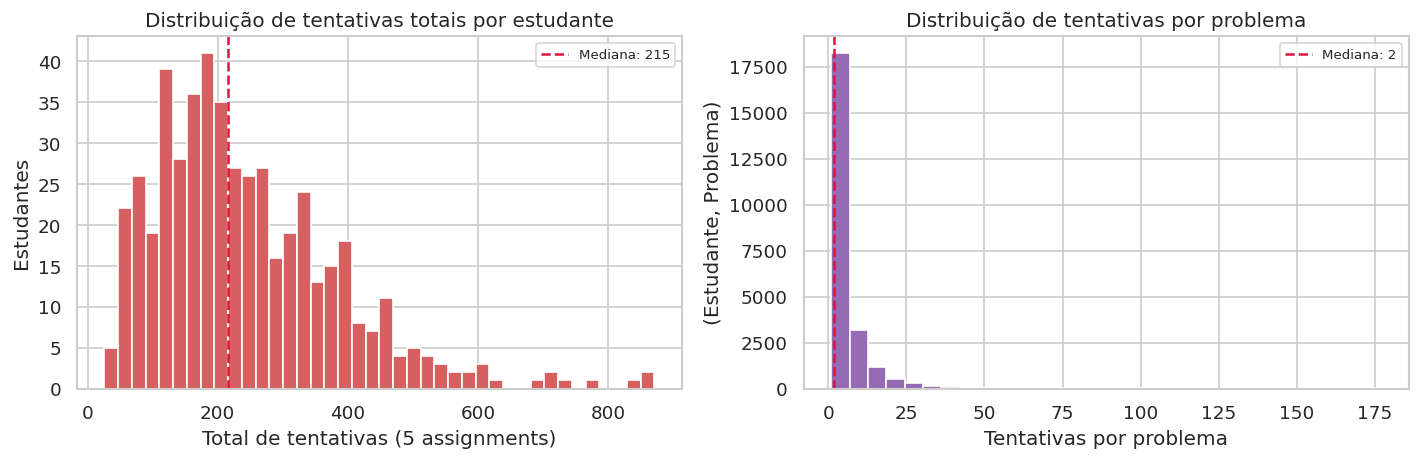

In [23]:
# Usando all_labels (early + late) para cobrir todos os 5 assignments
attempts_per_student = all_labels.groupby('SubjectID')['Attempts'].sum().rename('total_attempts')

print('Distribuição de tentativas totais por estudante (5 assignments):')
display(attempts_per_student.describe().rename('total_attempts').to_frame().T.round(1))

outlier_thresh = 200
outliers = (attempts_per_student >= outlier_thresh).sum()
print(f'\nEstudantes com >= {outlier_thresh} tentativas totais: {outliers} '
      f'({outliers / len(attempts_per_student) * 100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(attempts_per_student, bins=40, color=sns.color_palette('muted')[3], edgecolor='white')
axes[0].axvline(attempts_per_student.median(), color='crimson', linestyle='--',
                label=f'Mediana: {attempts_per_student.median():.0f}')
axes[0].set_xlabel('Total de tentativas (5 assignments)')
axes[0].set_ylabel('Estudantes')
axes[0].set_title('Distribuição de tentativas totais por estudante')
axes[0].legend(fontsize=8)

attempts_per_problem = all_labels['Attempts']
axes[1].hist(attempts_per_problem, bins=30, color=sns.color_palette('muted')[4], edgecolor='white')
axes[1].axvline(attempts_per_problem.median(), color='crimson', linestyle='--',
                label=f'Mediana: {attempts_per_problem.median():.0f}')
axes[1].set_xlabel('Tentativas por problema')
axes[1].set_ylabel('(Estudante, Problema)')
axes[1].set_title('Distribuição de tentativas por problema')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Estudantes que nunca resolveram nenhum problema: 0 (0.0%)
Estudantes com ao menos 1 problema sem resolver: 283 (57.3%)

Correlação Spearman (tentativas totais × X-Grade): 0.296


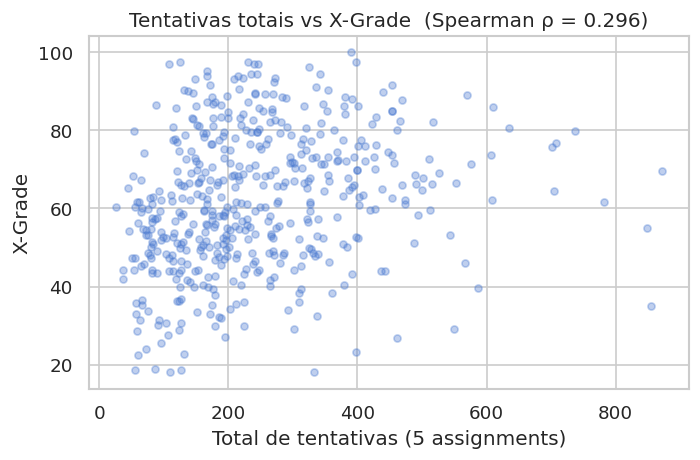

In [24]:
# Usando all_labels para cobrir os 5 assignments
solved_any   = all_labels.groupby('SubjectID')['CorrectEventually'].any()
never_solved = (~solved_any).sum()
print(f'Estudantes que nunca resolveram nenhum problema: {never_solved} '
      f'({never_solved / len(solved_any) * 100:.1f}%)')

solved_all = all_labels.groupby('SubjectID')['CorrectEventually'].all()
incomplete = (~solved_all).sum()
print(f'Estudantes com ao menos 1 problema sem resolver: {incomplete} '
      f'({incomplete / len(solved_all) * 100:.1f}%)')

student_summary = (
    attempts_per_student
    .to_frame()
    .join(subject.set_index('SubjectID')['X-Grade'])
)
corr = student_summary.corr(method='spearman').iloc[0, 1]
print(f'\nCorrelação Spearman (tentativas totais × X-Grade): {corr:.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(student_summary['total_attempts'], student_summary['X-Grade'],
           alpha=0.35, s=18, color=sns.color_palette('muted')[0])
ax.set_xlabel('Total de tentativas (5 assignments)')
ax.set_ylabel('X-Grade')
ax.set_title(f'Tentativas totais vs X-Grade  (Spearman ρ = {corr:.3f})')
plt.tight_layout()
plt.show()

**Achado:** Mediana de tentativas totais por estudante (5 assignments): 215; média 244.8 (±142.2); máximo 871. 54.0% dos estudantes realizaram ≥ 200 tentativas. Todos os estudantes resolveram ao menos um problema (0% sem acerto); 57.3% deixaram ao menos um problema sem resolver. A correlação Spearman entre tentativas totais e X-Grade é fraca e positiva (ρ = 0.296) — contrariando a hipótese de relação negativa.  
**Implicação para modelagem:** A correlação positiva indica que tentar mais problemas associa-se levemente a melhor desempenho, não a maior dificuldade — coerente com comportamento de estudantes engajados que exploram o sistema. O truncamento em 50 tentativas por sequência (Shi et al., 2022) é conservador dado que a mediana global é 215 tentativas distribuídas por múltiplos problemas. Os 57.3% com ao menos um problema não resolvido evidenciam que BKT com parâmetros únicos por KC não diferencia baixo engajamento de dificuldade persistente — o DKT e Code-DKT, ao modelar sequências individuais, capturam esse contínuo de forma mais fiel.

### 2.3 — Perfis de Estudante: Clustering Exploratório

**Contexto:** Identificar grupos naturais de estudantes com base em taxa de acerto eventual, número médio de tentativas por assignment e nota final documenta a heterogeneidade comportamental da turma. O agrupamento é exploratório — não alimenta os modelos de KT diretamente — mas evidencia por que sequências individualizadas são necessárias: perfis distintos implicam trajetórias de aprendizagem sistematicamente diferentes que um modelo de turma único não capturaria.  
**Hipótese:** K-Means com k=3 deve revelar perfis interpretáveis alinhados com X-Grade: Alto desempenho (grade > 70, alta taxa de acerto, poucas tentativas por problema), Médio (grade ~60) e Em risco (grade < 50, baixa taxa de acerto, muitas tentativas). O silhouette score deve apontar k=2 ou k=3 como ótimo.  
**Referência:** Shi et al. (2022); Abdelrahman et al. (2022).

Estudantes com features completas: 453 / 506
Features: ['A439_rate', 'A487_rate', 'A492_rate', 'A494_rate', 'A502_rate', 'A439_att', 'A487_att', 'A492_att', 'A494_att', 'A502_att', 'X-Grade']



,A439_rate,A487_rate,A492_rate,A494_rate,A502_rate,A439_att,A487_att,A492_att,A494_att,A502_att,X-Grade
count,453.00,453.00,453.0,453.00,453.00,453.00,453.00,453.00,453.00,453.00,453.00
mean,0.98,0.92,0.9,0.93,0.94,4.56,6.40,6.74,4.71,3.78,62.72
std,0.10,0.15,0.2,0.12,0.14,3.25,3.98,5.45,3.14,3.05,17.69
min,0.00,0.00,0.0,0.20,0.00,1.00,1.00,1.00,1.00,1.00,18.00
25%,1.00,0.90,0.9,0.90,1.00,2.30,3.50,2.60,2.30,1.44,49.89
50%,1.00,1.00,1.0,1.00,1.00,3.70,5.60,5.50,4.00,2.80,62.46
75%,1.00,1.00,1.0,1.00,1.00,5.80,8.20,9.20,6.30,5.20,76.45
max,1.00,1.00,1.0,1.00,1.00,28.20,27.90,38.20,18.20,23.60,100.00


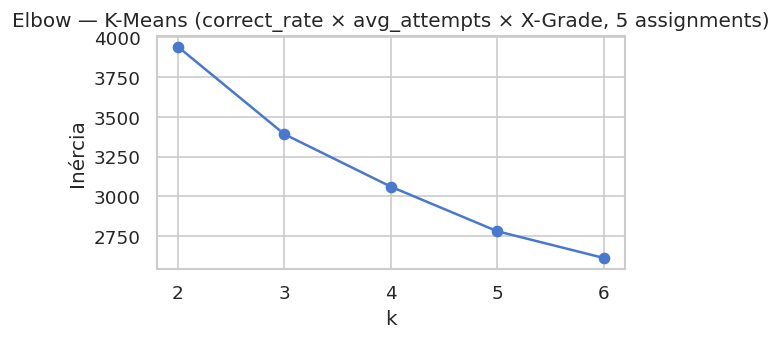

In [25]:
SEED = 42

avg_att_by_assignment = (
    all_labels.groupby(['SubjectID', 'AssignmentID'])['Attempts']
    .mean()
    .reset_index()
    .pivot(index='SubjectID', columns='AssignmentID', values='Attempts')
)
avg_att_by_assignment.columns = [f'A{c}_att' for c in avg_att_by_assignment.columns]

cluster_features = (
    correct_rate_by_assignment
    .join(avg_att_by_assignment)
    .join(subject.set_index('SubjectID')['X-Grade'])
    .dropna()
)

print(f'Estudantes com features completas: {len(cluster_features)} / {n_students}')
print(f'Features: {list(cluster_features.columns)}')
print()
display(cluster_features.describe().round(2))

X = cluster_features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = {k: KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 7)}

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(list(inertias.keys()), list(inertias.values()), 'o-', color=sns.color_palette('muted')[0])
ax.set_xlabel('k')
ax.set_ylabel('Inércia')
ax.set_title('Elbow — K-Means (correct_rate × avg_attempts × X-Grade, 5 assignments)')
plt.tight_layout()
plt.show()

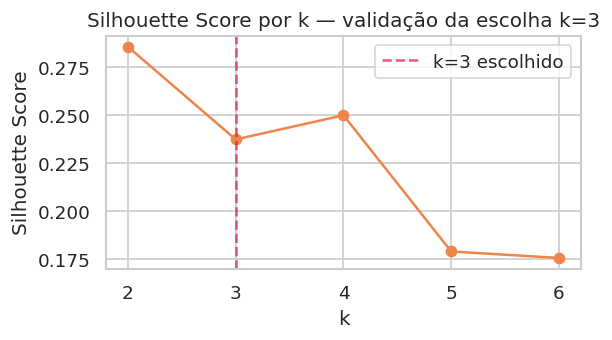

Silhouette Score por k: {2: 0.2854, 3: 0.2372, 4: 0.2498, 5: 0.1789, 6: 0.1756}
Melhor k pelo Silhouette: 2  |  Score (k=3): 0.2372


In [26]:
from sklearn.metrics import silhouette_score

K_range = range(2, 7)
sil_scores = []
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels_tmp))

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(list(K_range), sil_scores, 'o-', color=sns.color_palette('muted')[1])
ax.axvline(x=3, color='crimson', linestyle='--', alpha=0.7, label='k=3 escolhido')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por k — validação da escolha k=3')
ax.legend()
plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'Silhouette Score por k: {dict(zip(K_range, [round(s, 4) for s in sil_scores]))}')
print(f'Melhor k pelo Silhouette: {best_k}  |  Score (k=3): {sil_scores[1]:.4f}')

=== Resumo por perfil ===


,N,X-Grade,A439_rate,A487_rate,A492_rate,A494_rate,A502_rate,A439_att,A487_att,A492_att,A494_att,A502_att
perfil,,,,,,,,,,,,
Alto desempenho,139,73.79,0.99,0.95,0.94,0.95,0.96,4.4,9.2,10.9,7.5,6.3
Em risco,248,55.94,0.99,0.95,0.97,0.98,0.98,4.3,4.6,3.6,2.7,2.0
Médio,66,64.92,0.89,0.73,0.56,0.73,0.77,5.8,7.2,9.7,6.3,5.1


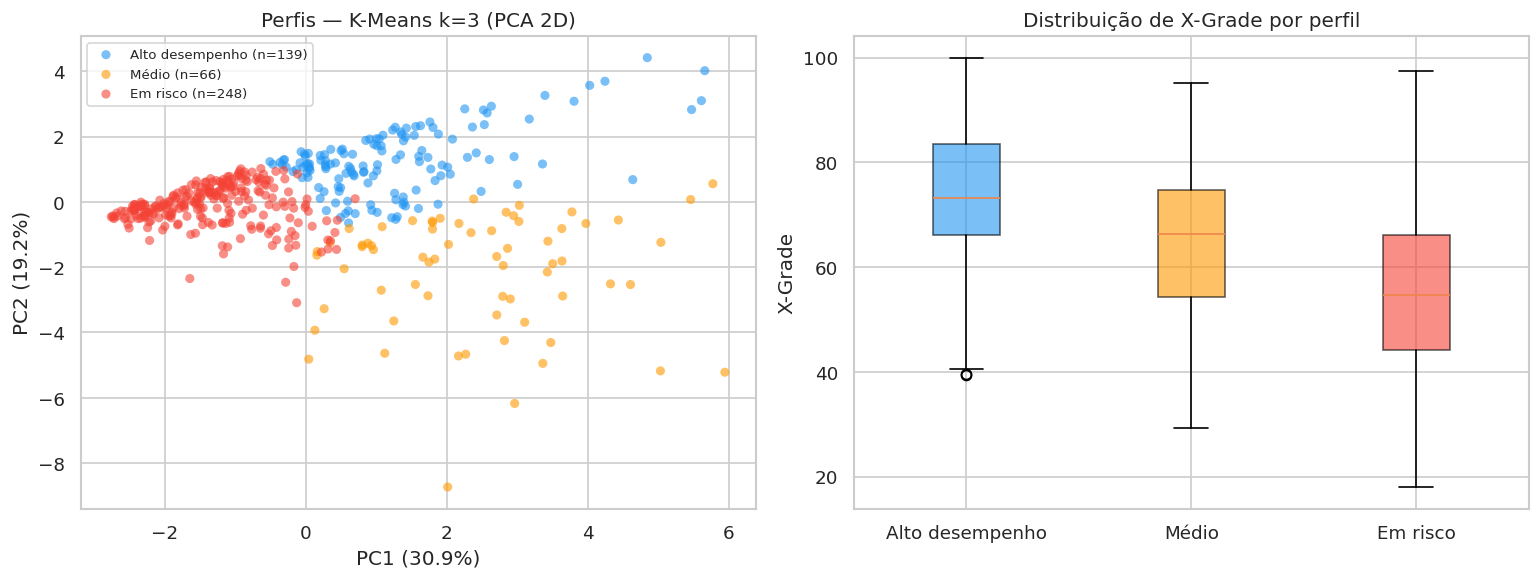

In [27]:
K_BEST = 3
km = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
cluster_features = cluster_features.copy()
cluster_features['cluster'] = km.fit_predict(X_scaled)

# Nomear clusters pelo X-Grade médio
grade_by_cluster = cluster_features.groupby('cluster')['X-Grade'].mean().sort_values(ascending=False)
cluster_labels = {c: lbl for c, lbl in zip(grade_by_cluster.index,
                                             ['Alto desempenho', 'Médio', 'Em risco'])}
cluster_features['perfil'] = cluster_features['cluster'].map(cluster_labels)

# Tabela resumo separada: taxas de acerto | tentativas por assignment
rate_cols = [c for c in cluster_features.columns if c.endswith('_rate')]
att_cols  = [c for c in cluster_features.columns if c.endswith('_att')]

summary_base = cluster_features.groupby('perfil')[['X-Grade']].mean().round(2)
summary_base.insert(0, 'N', cluster_features.groupby('perfil').size())

summary_rate = cluster_features.groupby('perfil')[rate_cols].mean().round(2)
summary_att  = cluster_features.groupby('perfil')[att_cols].mean().round(1)

print('=== Resumo por perfil ===')
display(pd.concat([summary_base, summary_rate, summary_att], axis=1))

# Projeção PCA 2D
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_scaled)

palette = {'Alto desempenho': '#2196F3', 'Médio': '#FF9800', 'Em risco': '#F44336'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PCA scatter
for perfil, color in palette.items():
    mask = cluster_features['perfil'] == perfil
    n = mask.sum()
    axes[0].scatter(coords[mask, 0], coords[mask, 1], label=f'{perfil} (n={n})',
                    color=color, alpha=0.6, s=30, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Perfis — K-Means k=3 (PCA 2D)')
axes[0].legend(fontsize=8)

# Boxplot de X-Grade por perfil
order = ['Alto desempenho', 'Médio', 'Em risco']
data_box = [cluster_features[cluster_features['perfil'] == p]['X-Grade'] for p in order]
bp = axes[1].boxplot(data_box, tick_labels=order, patch_artist=True)
colors = [palette[p] for p in order]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('X-Grade')
axes[1].set_title('Distribuição de X-Grade por perfil')

plt.tight_layout()
plt.show()

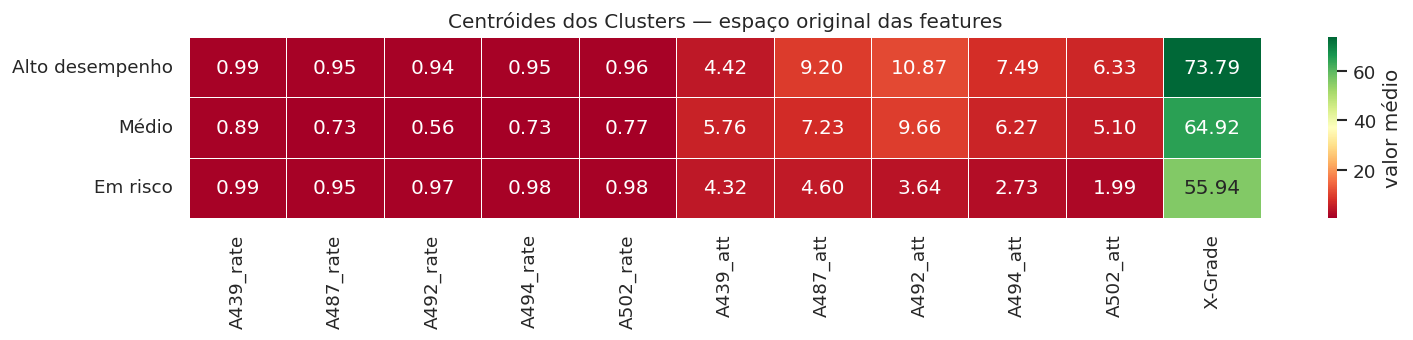

In [28]:
feature_cols = [c for c in cluster_features.columns if c not in ('cluster', 'perfil')]

# Centróides no espaço original (inverter StandardScaler), respeitando mapeamento cluster → perfil
order = ['Alto desempenho', 'Médio', 'Em risco']
centroid_rows = {
    label: scaler.inverse_transform(km.cluster_centers_[cid].reshape(1, -1))[0]
    for cid, label in cluster_labels.items()
}
centroid_df = pd.DataFrame(centroid_rows, index=feature_cols).T.loc[order]

fig, ax = plt.subplots(figsize=(13, 3))
sns.heatmap(centroid_df, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'valor médio'})
ax.set_title('Centróides dos Clusters — espaço original das features')
plt.tight_layout()
plt.show()

**Achado:** K-Means com k=3 (SEED=42) sobre 453 estudantes com features completas revela três perfis ordenados por X-Grade médio. O silhouette score favorece k=2 (0.285) sobre k=3 (0.237), mas k=3 é preferido pela interpretabilidade do perfil intermediário. Os perfis identificados são:

| Perfil | N | X-Grade médio | Taxa de acerto eventual | Tentativas médias/assignment |
|---|---|---|---|---|
| **Alto desempenho** | 139 (30.7%) | 73.8 | 94–99% | 4.4–10.9 |
| **Médio** | 66 (14.6%) | 64.9 | 56–89% (mínimo em A492) | 5.1–9.7 |
| **Em risco** | 248 (54.7%) | 55.9 | 97–99% (inesperadamente alto) | 2.0–4.6 (muito baixo) |

Resultado inesperado: o cluster "Em risco" (54.7% da turma) apresenta taxas de acerto eventual tão altas quanto o "Alto desempenho", mas com número de tentativas médio muito menor (2–4.6/assignment). O cluster "Médio" é o que exibe menor taxa de acerto e mais tentativas — padrão de dificuldade persistente real. O perfil "Em risco" (grade ~55.9) parece representar estudantes com baixo engajamento — que tentam poucos problemas — e não necessariamente estudantes que erram muito. Esta interpretação é coerente com o achado de ρ = 0.296 (Seção 2.2): tentar mais associa-se a melhor desempenho, não a dificuldade.

**Implicação para modelagem:** A heterogeneidade não se organiza na estrutura esperada (dificuldade ↔ tentativas ↔ grade). O perfil "Em risco" evidencia que baixo engajamento é o padrão dominante nesta população, não dificuldade persistente. O DKT e o Code-DKT, ao modelar sequências individualizadas, capturam implicitamente esses comportamentos; o BKT com parâmetros compartilhados por KC não diferencia engajamento seletivo de baixa maestria. Silhouette < 0.30 confirma fronteiras suaves entre perfis — o KT deve modelar um contínuo de habilidades, não grupos discretos.